In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nInformation:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape of Dataset: (7043, 21)

Columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-nu

In [5]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Remove Customer ID

df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


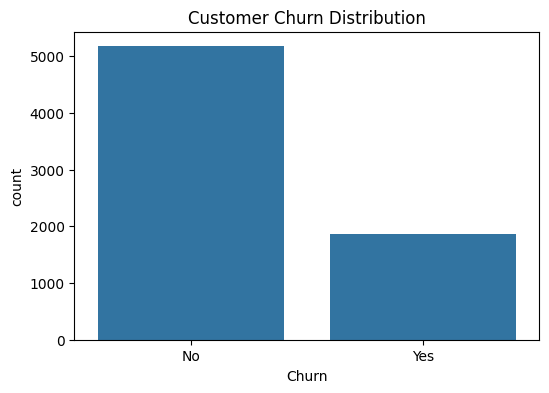

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

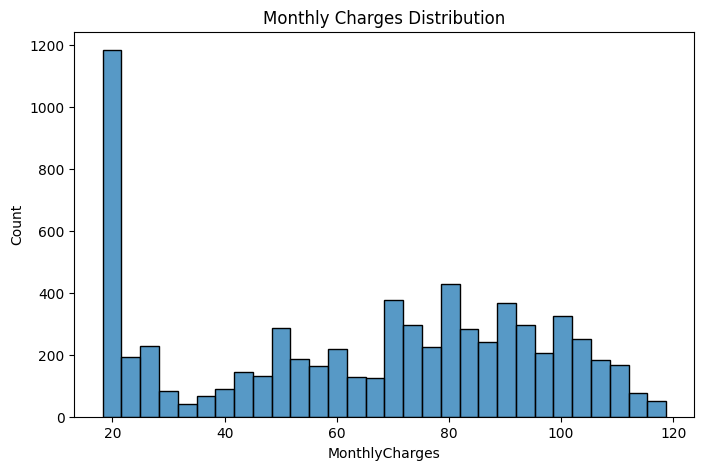

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.show()

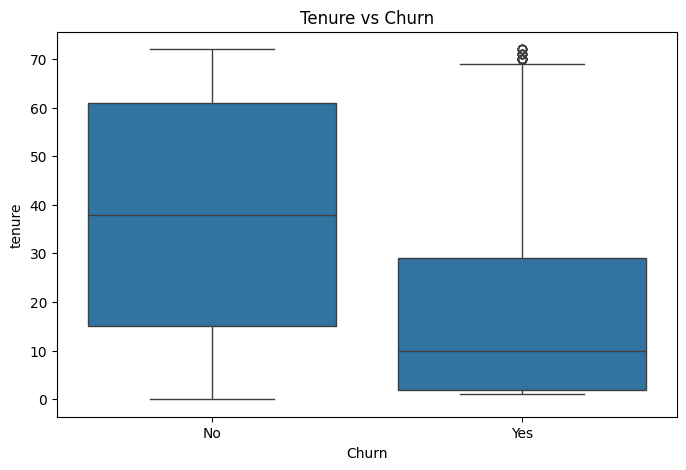

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

In [9]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [10]:
X = df.drop('Churn', axis=1)

y = df['Churn']

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (5634, 19)
Testing Samples : (1409, 19)


In [11]:
def create_baseline_model():

    model = Sequential()

    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    return model

In [12]:
sgd_model = create_baseline_model()

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_sgd, acc_sgd = sgd_model.evaluate(X_test, y_test)

print("SGD Accuracy :", acc_sgd)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7002 - loss: 0.5705 - val_accuracy: 0.7524 - val_loss: 0.4924
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7553 - loss: 0.4819 - val_accuracy: 0.7657 - val_loss: 0.4547
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7781 - loss: 0.4563 - val_accuracy: 0.7782 - val_loss: 0.4405
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7852 - loss: 0.4452 - val_accuracy: 0.7835 - val_loss: 0.4342
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7868 - loss: 0.4394 - val_accuracy: 0.7835 - val_loss: 0.4306
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7879 - loss: 0.4358 - val_accuracy: 0.7879 - val_loss: 0.4282
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7908 - loss: 0.4329 - val_accuracy: 0.7897 - val_loss: 0.4263
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7903 - loss: 0.4307 - val_accuracy: 0.

In [14]:
adam_model = create_baseline_model()

adam_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_adam = adam_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_adam, acc_adam = adam_model.evaluate(X_test, y_test)

print("Adam Accuracy :", acc_adam)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7269 - loss: 0.5260 - val_accuracy: 0.7941 - val_loss: 0.4308
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7890 - loss: 0.4337 - val_accuracy: 0.7995 - val_loss: 0.4190
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7957 - loss: 0.4246 - val_accuracy: 0.8128 - val_loss: 0.4119
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8023 - loss: 0.4192 - val_accuracy: 0.8021 - val_loss: 0.4093
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8065 - loss: 0.4136 - val_accuracy: 0.8057 - val_loss: 0.4128
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8054 - loss: 0.4123 - val_accuracy: 0.8066 - val_loss: 0.4115
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8065 - loss: 0.4073 - val_accuracy: 0.8066 - val_loss: 0.4131
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8092 - loss: 0.4042 - val_accuracy: 0.

In [15]:
rms_model = create_baseline_model()

rms_model.compile(
    optimizer=RMSprop(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_rms = rms_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_rms, acc_rms = rms_model.evaluate(X_test, y_test)

print("RMSprop Accuracy :", acc_rms)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7619 - loss: 0.4815 - val_accuracy: 0.7888 - val_loss: 0.4248
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7921 - loss: 0.4354 - val_accuracy: 0.8110 - val_loss: 0.4144
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7963 - loss: 0.4261 - val_accuracy: 0.8092 - val_loss: 0.4123
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8012 - loss: 0.4202 - val_accuracy: 0.8092 - val_loss: 0.4107
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8023 - loss: 0.4156 - val_accuracy: 0.8021 - val_loss: 0.4101
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8101 - loss: 0.4115 - val_accuracy: 0.8083 - val_loss: 0.4097
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8127 - loss: 0.4083 - val_accuracy: 0.8030 - val_loss: 0.4121
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8130 - loss: 0.4062 - val_accuracy: 0.

In [16]:
dropout_model = Sequential()

dropout_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
dropout_model.add(Dropout(0.3))

dropout_model.add(Dense(32, activation='relu'))
dropout_model.add(Dropout(0.2))

dropout_model.add(Dense(1, activation='sigmoid'))

dropout_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_dropout, acc_dropout = dropout_model.evaluate(X_test, y_test)

print("Dropout Accuracy :", acc_dropout)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7344 - loss: 0.5212 - val_accuracy: 0.8012 - val_loss: 0.4331
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7746 - loss: 0.4564 - val_accuracy: 0.7959 - val_loss: 0.4201
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7839 - loss: 0.4528 - val_accuracy: 0.8039 - val_loss: 0.4156
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7888 - loss: 0.4413 - val_accuracy: 0.8012 - val_loss: 0.4149
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4369 - val_accuracy: 0.7995 - val_loss: 0.4135
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7914 - loss: 0.4364 - val_accuracy: 0.7986 - val_loss: 0.4121
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7941 - loss: 0.4344 - val_accuracy: 0.8030 - val_loss: 0.4122
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4312 - val_accuracy: 0.

In [17]:
batch_model = Sequential()

batch_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
batch_model.add(BatchNormalization())

batch_model.add(Dense(32, activation='relu'))
batch_model.add(BatchNormalization())

batch_model.add(Dense(1, activation='sigmoid'))

batch_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_batch = batch_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_batch, acc_batch = batch_model.evaluate(X_test, y_test)

print("Batch Normalization Accuracy :", acc_batch)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7116 - loss: 0.5649 - val_accuracy: 0.7808 - val_loss: 0.4679
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7870 - loss: 0.4507 - val_accuracy: 0.7941 - val_loss: 0.4341
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7921 - loss: 0.4329 - val_accuracy: 0.7941 - val_loss: 0.4246
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7968 - loss: 0.4190 - val_accuracy: 0.7941 - val_loss: 0.4242
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7994 - loss: 0.4196 - val_accuracy: 0.7950 - val_loss: 0.4253
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8052 - loss: 0.4091 - val_accuracy: 0.7986 - val_loss: 0.4320
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8101 - loss: 0.4009 - val_accuracy: 0.7933 - val_loss: 0.4258
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.3978 - val_accuracy: 0.

In [18]:
final_model = Sequential()

final_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.3))

final_model.add(Dense(32, activation='relu'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.2))

final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss_final, acc_final = final_model.evaluate(X_test, y_test)

print("Dropout + Batch Normalization Accuracy :", acc_final)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6911 - loss: 0.6149 - val_accuracy: 0.7791 - val_loss: 0.5000
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7550 - loss: 0.5117 - val_accuracy: 0.7879 - val_loss: 0.4467
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7755 - loss: 0.4731 - val_accuracy: 0.7915 - val_loss: 0.4314
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7748 - loss: 0.4643 - val_accuracy: 0.7933 - val_loss: 0.4287
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7799 - loss: 0.4583 - val_accuracy: 0.7995 - val_loss: 0.4240
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7894 - loss: 0.4485 - val_accuracy: 0.8039 - val_loss: 0.4219
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7897 - loss: 0.4410 - val_accuracy: 0.7977 - val_loss: 0.4223
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7890 - loss: 0.4446 - val_accuracy: 0.

In [19]:
results = pd.DataFrame({
    'Model': [
        'SGD',
        'Adam',
        'RMSprop',
        'Dropout',
        'Batch Normalization',
        'Dropout + BatchNorm'
    ],
    'Accuracy': [
        acc_sgd,
        acc_adam,
        acc_rms,
        acc_dropout,
        acc_batch,
        acc_final
    ]
})

print(results)

                 Model  Accuracy
0                  SGD  0.805536
1                 Adam  0.799858
2              RMSprop  0.804116
3              Dropout  0.811214
4  Batch Normalization  0.794890
5  Dropout + BatchNorm  0.811923


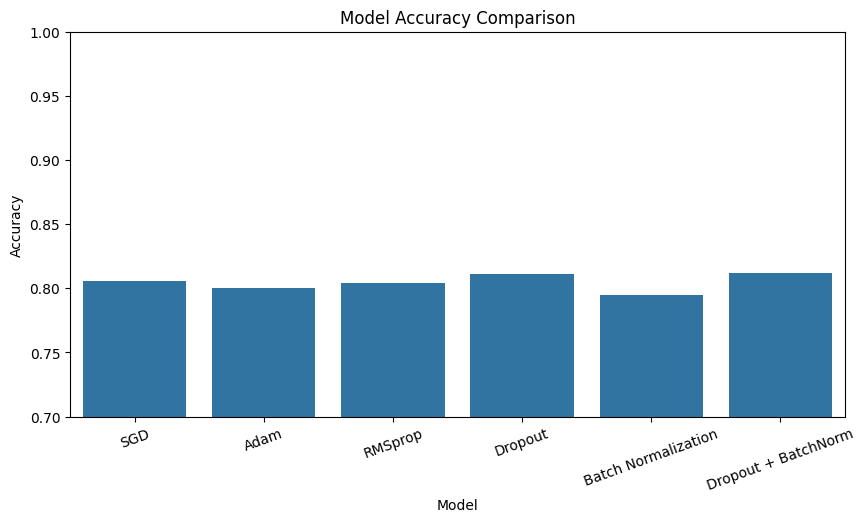

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0.70,1.0)

plt.show()

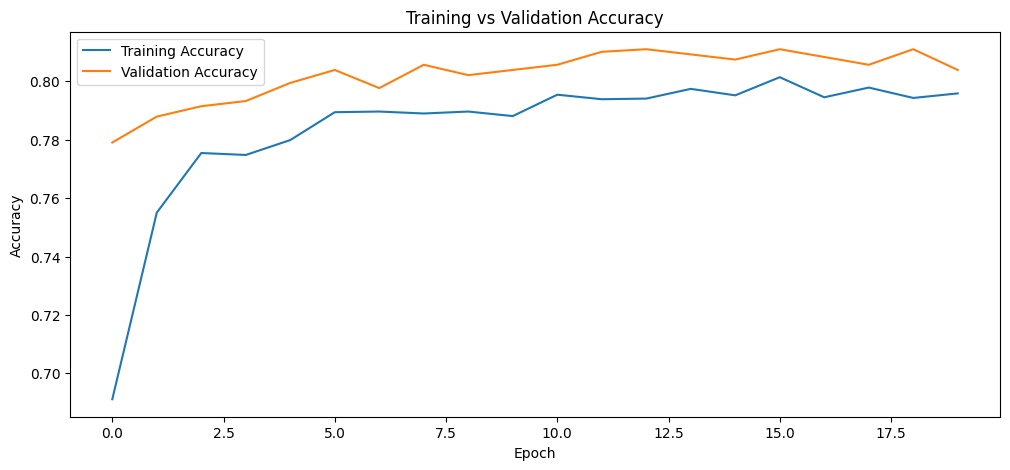

In [21]:
plt.figure(figsize=(12,5))

plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

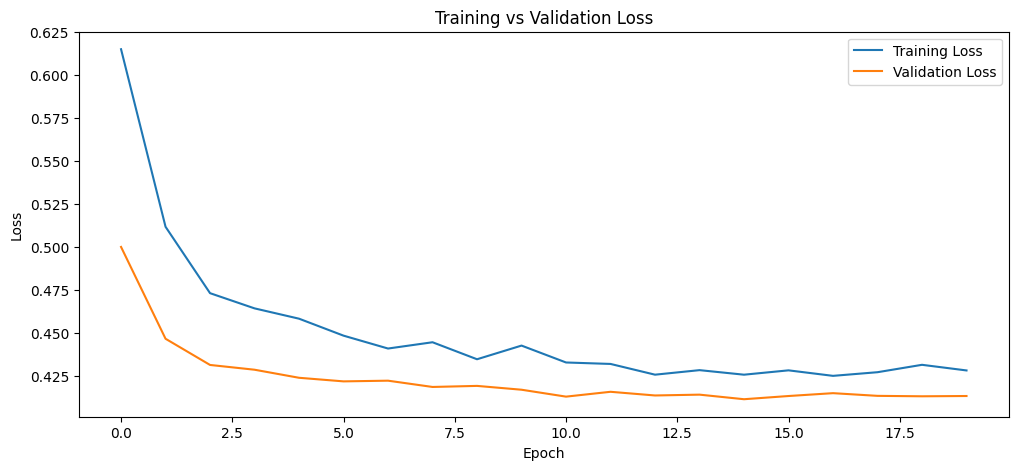

In [22]:
plt.figure(figsize=(12,5))

plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


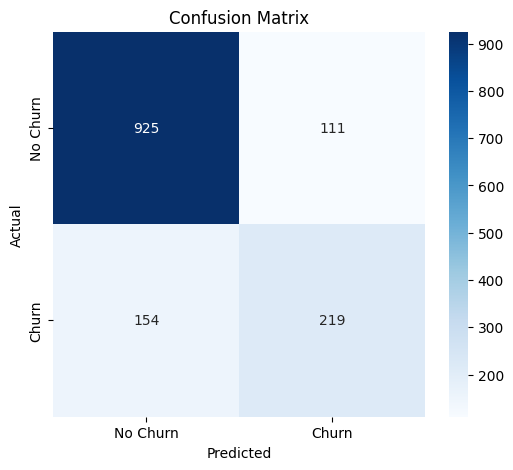

In [23]:
pred = final_model.predict(X_test)

pred = (pred > 0.5).astype(int)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [24]:
print("Classification Report\n")

print(classification_report(y_test, pred))

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1036
           1       0.66      0.59      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [25]:
results = results.sort_values(by='Accuracy', ascending=False)

print(results)

                 Model  Accuracy
5  Dropout + BatchNorm  0.811923
3              Dropout  0.811214
0                  SGD  0.805536
2              RMSprop  0.804116
1                 Adam  0.799858
4  Batch Normalization  0.794890


In [26]:
best_model = results.iloc[0]

print("="*60)
print("CUSTOMER CHURN PREDICTION USING DEEP LEARNING")
print("="*60)

print(f"\nBest Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print("\nConclusion:")
print("• Adam optimizer generally converges faster than SGD.")
print("• RMSprop also performs well for this dataset.")
print("• Dropout helps reduce overfitting.")
print("• Batch Normalization stabilizes training and speeds convergence.")
print("• Combining Dropout and Batch Normalization provides better generalization.")
print("• This model can effectively predict customer churn.")

CUSTOMER CHURN PREDICTION USING DEEP LEARNING

Best Model : Dropout + BatchNorm
Accuracy   : 0.8119

Conclusion:
• Adam optimizer generally converges faster than SGD.
• RMSprop also performs well for this dataset.
• Dropout helps reduce overfitting.
• Batch Normalization stabilizes training and speeds convergence.
• Combining Dropout and Batch Normalization provides better generalization.
• This model can effectively predict customer churn.
